In [1]:
from sklearn.ensemble import IsolationForest  # the model we use to detect if someone is an impostor
from sklearn.preprocessing import StandardScaler  # used to bring all features to the same scale so no feature dominates
import matplotlib.pyplot as plt  # used to draw the FAR/FRR graph
import joblib  # used to save the trained model to a file so we can reuse it later
import pandas as pd  # used to load and work with csv files as tables
import numpy as np  # used for math operations like mean, array stuff


In [2]:
FEATURES_FILE = "../data/features.csv"  # path to the genuine user features file
ANOMALOUS_FEATURES_FILE = "../data/features_anomalous.csv"  # path to the impostor features file

CONTAMINATION = 0.05  # we tell the model to expect 5% of training data to look weird (noise tolerance)
RANDOM_STATE = 42  # fixes randomness so we get the same result every time we run
TRAIN_FRACTION = 0.8  # 80% of genuine data goes to training, 20% is kept for testing

WINDOW_SIZE = 50  # each feature row was made from a sliding window of 50 keystrokes
SLIDE_STEP = 10  # the window moves 10 keystrokes forward each time, so windows overlap


In [9]:
genuine_df = pd.read_csv(FEATURES_FILE)  # load the real users keystroke features into a table
impostor_df = pd.read_csv(ANOMALOUS_FEATURES_FILE)  # load the impostors keystroke features into a table

# typing_speed and backspace_rate are removed because they look almost identical
# between the real user and impostors (Cohens d < 0.05) so they confuse the model more than they help
feature_columns = [
    "avg_dwell",   # average time a key is held down - unique per person
    "std_dwell",   # how much the hold time varies - captures consistency
    "avg_flight",  # average time between releasing one key and pressing the next
    "std_flight",  # how much the between-key time varies
    "typing_speed",
    "backspace_rate",
    "avg_space_dwells",
    "overlap_rate",
    "long_pause_rate"
]

genuine_features = genuine_df[feature_columns]  # keep only the 4 useful columns from genuine data
impostor_features = impostor_df[feature_columns]  # keep only the 4 useful columns from impostor data


In [10]:
print(genuine_features.head())  # quickly check the first 5 rows of genuine data look right
print(impostor_features.head())  # quickly check the first 5 rows of impostor data look right


   avg_dwell  std_dwell  avg_flight  std_flight  typing_speed  backspace_rate  \
0   0.101832   0.030881    0.070388    0.057963      7.201116            0.06   
1   0.104940   0.030144    0.059171    0.041280      7.800411            0.00   
2   0.104135   0.028679    0.053929    0.039725      8.070607            0.00   
3   0.099056   0.025110    0.057573    0.041903      8.061798            0.04   
4   0.102301   0.028375    0.054644    0.041367      8.187376            0.04   

   avg_space_dwells  overlap_rate  long_pause_rate  
0          0.129986          0.32              0.0  
1          0.125424          0.38              0.0  
2          0.127432          0.42              0.0  
3          0.118692          0.38              0.0  
4          0.118645          0.42              0.0  
   avg_dwell  std_dwell  avg_flight  std_flight  typing_speed  backspace_rate  \
0   0.092071   0.028322    0.118202    0.202125      2.417366             0.0   
1   0.095037   0.031270    0.1190

In [11]:
gap_windows = WINDOW_SIZE // SLIDE_STEP
# windows overlap because they slide by only 10 keystrokes but are 50 long
# so rows near the train/test boundary share raw keystroke data
# we skip gap_windows rows on each side to prevent leakage between train and test

split_point = int(len(genuine_features) * TRAIN_FRACTION)  # index where training ends and testing begins

genuine_train = genuine_features.iloc[:split_point - gap_windows]  # rows before the split minus gap go to training
genuine_test = genuine_features.iloc[split_point + gap_windows:]  # rows after the split plus gap go to testing


In [12]:
scaler = StandardScaler()  # create the scaler - it will make each feature have mean=0 and std=1

genuine_train_scaled = scaler.fit_transform(genuine_train)
# fit   = learn the mean and std of each feature FROM the training data
# transform = use those learned values to rescale the training data
# both steps happen together here

genuine_test_scaled = scaler.transform(genuine_test)
# only transform here, no fit - we use the SAME mean/std learned from training
# this is important: test data must be scaled the same way as training data

impostor_scaled = scaler.transform(impostor_features)
# same thing for impostor - apply the training scale so scores are comparable


In [13]:
isolation_forest = IsolationForest(
    n_estimators=200,        # build 200 random trees - more trees = more stable results
    contamination=CONTAMINATION,  # tell the model 5% of training data might be noisy
    random_state=RANDOM_STATE     # fix randomness so results are reproducible
)

isolation_forest.fit(genuine_train_scaled)
# train the model using ONLY genuine user data
# it learns what normal typing looks like for this person
# it never sees impostor data - it just learns the genuine pattern


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [14]:
# decision_function() scores each window
# positive = looks normal (like the genuine user)
# negative = looks anomalous (like an impostor)
# we flip the sign with - so that a HIGH score means MORE suspicious
# this makes it easier to reason about: higher score = more likely an impostor

genuine_anomaly_scores = -isolation_forest.decision_function(genuine_test_scaled)
# score the genuine test windows - these should come out LOW (they are not suspicious)

impostor_anomaly_scores = -isolation_forest.decision_function(impostor_scaled)
# score the impostor windows - these should come out HIGH (they are suspicious)

# Note on Isolation Forest decision_function:
# - During fit(), the model calculates raw anomaly scores and sets `offset_` 
#   to the Nth percentile based on the `contamination` rate (e.g., 5th percentile for 0.05).
# - `decision_function(X) = score_samples(X) - offset_`, which re-centers that cutoff to 0.
# - Interpretation:
#     * < 0  : Anomalies / Outliers (predict returns -1)
#     * >= 0 : Normal / Inliers     (predict returns +1)


In [15]:
# wrap the numpy arrays in pandas Series so we can use .describe() easily
# .describe() gives count, mean, std, min, 25%, 50%, 75%, max in one shot

print("Genuine:")
print(pd.Series(genuine_anomaly_scores).describe())  # should show a low mean

print("\nImpostor:")
print(pd.Series(impostor_anomaly_scores).describe())  # should show a higher mean
# if both means are close together, the model cant tell them apart well


Genuine:
count    200.000000
mean      -0.112053
std        0.059211
min       -0.183390
25%       -0.148029
50%       -0.127672
75%       -0.096309
max        0.120555
dtype: float64

Impostor:
count    1011.000000
mean       -0.001735
std         0.046444
min        -0.099924
25%        -0.034693
50%        -0.006913
75%         0.021492
max         0.168819
dtype: float64


In [16]:
def compute_far_frr(genuine_scores, impostor_scores, threshold):
    # FAR = False Acceptance Rate = fraction of impostors the model wrongly lets through
    # FRR = False Rejection Rate  = fraction of genuine users the model wrongly blocks

    false_rejection_rate = np.mean(genuine_scores > threshold)
    # genuine score above threshold means the model thought the real user looked suspicious
    # that is wrong - genuine user got blocked - so this is a false rejection

    false_acceptance_rate = np.mean(impostor_scores <= threshold)
    # impostor score below threshold means the model thought the impostor looked normal
    # that is wrong - impostor got let in - so this is a false acceptance

    return false_acceptance_rate, false_rejection_rate


In [17]:
thresholds = np.linspace(
    min(genuine_anomaly_scores.min(), impostor_anomaly_scores.min()),  # start from the lowest score across both groups
    max(genuine_anomaly_scores.max(), impostor_anomaly_scores.max()),  # end at the highest score across both groups
    100  # test 100 evenly spaced threshold values between min and max
)
# by sweeping all possible thresholds we can find which one gives the best balance of FAR and FRR


In [18]:
far_values = []  # will store FAR for each threshold we try
frr_values = []  # will store FRR for each threshold we try

for threshold in thresholds:  # loop through every threshold one by one

    far_at_threshold, frr_at_threshold = compute_far_frr(
        genuine_anomaly_scores,
        impostor_anomaly_scores,
        threshold  # compute FAR and FRR at this specific threshold
    )

    far_values.append(far_at_threshold)  # save the FAR for this threshold
    frr_values.append(frr_at_threshold)  # save the FRR for this threshold


In [19]:
far_frr_differences = np.abs(np.array(far_values) - np.array(frr_values))
# at each threshold, calculate how far apart FAR and FRR are
# we want the threshold where they are closest to each other - that is the EER point

eer_index = np.argmin(far_frr_differences)  # index where FAR and FRR are closest

eer_threshold = thresholds[eer_index]  # the actual threshold value at that index
# this is the threshold we would use when deploying the model in real time

eer = (far_values[eer_index] + frr_values[eer_index]) / 2
# EER is the average of FAR and FRR at the crossover point
# lower EER = better model. 0% = perfect, 50% = random guessing


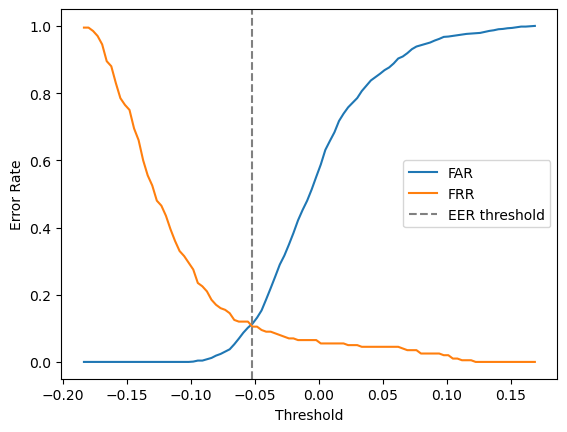

In [20]:
plt.plot(thresholds, far_values, label="FAR")  # draw the FAR line - goes DOWN as threshold increases
plt.plot(thresholds, frr_values, label="FRR")  # draw the FRR line - goes UP as threshold increases
# raising threshold = harder to get flagged = fewer impostors blocked (FAR down) but more genuine blocked (FRR up)

plt.axvline(
    eer_threshold,
    color="gray",
    linestyle="--",
    label="EER threshold"  # vertical line at the point where FAR and FRR cross
)

plt.xlabel("Threshold")  # x axis = the threshold value being tested
plt.ylabel("Error Rate")  # y axis = the error rate (0.0 to 1.0)
plt.legend()  # show labels so we know which line is FAR and which is FRR
plt.show()  # display the plot


In [21]:
print("EER threshold:", eer_threshold)  # use this value as the cutoff when running the model live
print("EER:", eer)  # the equal error rate - lower is better

print("FAR at EER:", far_values[eer_index])  # what fraction of impostors slip through at this threshold
print("FRR at EER:", frr_values[eer_index])  # what fraction of genuine users get wrongly blocked


EER threshold: -0.051756164847730046
EER: 0.10937438180019782
FAR at EER: 0.11374876360039565
FRR at EER: 0.105


In [23]:
joblib.dump(isolation_forest, "../isolation_forest_model.pkl")
joblib.dump(scaler, "../scaler.pkl")  # save scaler so inference can apply the same scaling

['../isolation_forest_model.pkl']